## 0.1 After merged the dataset from (Kaggle's train & test csv with IMDB's rating)

In [1]:
import pandas as pd
import numpy as np

In [3]:
test = pd.read_csv("result/test_merged.csv", sep = ',', header = 'infer')
test.head()

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,tconst,averageRating
0,3001,"[{'id': 34055, 'name': 'Pokémon Collection', '...",0,"[{'id': 12, 'name': 'Adventure'}, {'id': 16, '...",http://www.pokemon.com/us/movies/movie-pokemon...,tt1226251,ja,ディアルガVSパルキアVSダークライ,Ash and friends (this time accompanied by newc...,3.851534,...,90.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Somewhere Between Time & Space... A Legend Is ...,Pokémon: The Rise of Darkrai,"[{'id': 11451, 'name': 'pok√©mon'}, {'id': 115...","[{'cast_id': 3, 'character': 'Tonio', 'credit_...","[{'credit_id': '52fe44e7c3a368484e03d683', 'de...",tt1226251,6.4
1,3002,NaN,88000,"[{'id': 27, 'name': 'Horror'}, {'id': 878, 'na...",NaN,tt0051380,en,Attack of the 50 Foot Woman,When an abused wife grows to giant size becaus...,3.559789,...,65.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,A titanic beauty spreads a macabre wave of hor...,Attack of the 50 Foot Woman,"[{'id': 9748, 'name': 'revenge'}, {'id': 9951,...","[{'cast_id': 2, 'character': 'Nancy Fowler Arc...","[{'credit_id': '55807805c3a3685b1300060b', 'de...",tt0051380,5.1
2,3003,NaN,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",NaN,tt0118556,en,Addicted to Love,Good-natured astronomer Sam is devastated when...,8.085194,...,100.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,A Comedy About Lost Loves And Last Laughs,Addicted to Love,"[{'id': 931, 'name': 'jealousy'}, {'id': 9673,...","[{'cast_id': 11, 'character': 'Maggie', 'credi...","[{'credit_id': '52fe4330c3a36847f8041367', 'de...",tt0118556,6.1
3,3004,NaN,6800000,"[{'id': 18, 'name': 'Drama'}, {'id': 10752, 'n...",http://www.sonyclassics.com/incendies/,tt1255953,fr,Incendies,A mother's last wishes send twins Jeanne and S...,8.596012,...,130.0,"[{'iso_639_1': 'fr', 'name': 'Français'}, {'is...",Released,The search began at the opening of their mothe...,Incendies,"[{'id': 378, 'name': 'prison'}, {'id': 539, 'n...","[{'cast_id': 6, 'character': 'Nawal', 'credit_...","[{'credit_id': '56478092c3a36826140043af', 'de...",tt1255953,8.3
4,3005,NaN,2000000,"[{'id': 36, 'name': 'History'}, {'id': 99, 'na...",NaN,tt0418753,en,Inside Deep Throat,"In 1972, a seemingly typical shoestring budget...",3.217680,...,92.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It was filmed in 6 days for 25 thousand dollar...,Inside Deep Throat,"[{'id': 279, 'name': 'usa'}, {'id': 1228, 'nam...","[{'cast_id': 1, 'character': 'Narrator (voice)...","[{'credit_id': '52fe44ce9251416c75041967', 'de...",tt0418753,6.7


In [4]:
train = pd.read_csv("result/train_merged.csv", sep = ',', header = 'infer')
train.head()

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,...,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue,tconst,averageRating
0,1,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651,tt2637294,5.0
1,2,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...","[{'credit_id': '52fe43fe9251416c7502563d', 'de...",95149435,tt0368933,5.9
2,3,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...","[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",13092000,tt2582802,8.5
3,4,NaN,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,...,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Kahaani,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...","[{'credit_id': '52fe48779251416c9108d6eb', 'de...",16000000,tt1821480,8.1
4,5,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,...,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",Released,NaN,Marine Boy,NaN,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...","[{'credit_id': '52fe464b9251416c75073b43', 'de...",3923970,tt1380152,5.7


check with data type

In [18]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     3000 non-null   int64  
 1   belongs_to_collection  604 non-null    object 
 2   budget                 3000 non-null   int64  
 3   genres                 2993 non-null   object 
 4   homepage               946 non-null    object 
 5   imdb_id                3000 non-null   object 
 6   original_language      3000 non-null   object 
 7   original_title         3000 non-null   object 
 8   overview               2992 non-null   object 
 9   popularity             3000 non-null   float64
 10  poster_path            2999 non-null   object 
 11  production_companies   2844 non-null   object 
 12  production_countries   2945 non-null   object 
 13  release_date           3000 non-null   object 
 14  runtime                2998 non-null   float64
 15  spok

## Cleaning the data. Code is in data_clearning.py

After clearning. The datasets called train_cleaned.csv and test_clearned.csv
1. JSON columns processed and standardized
2. Numeric columns cleaned and outliers handled
3. Dates standardized and components extracted
4. Text columns cleaned and standardized
5. Missing values handled appropriately
6. Training data rows with missing ratings removed

In [19]:
# check with clearn datasets
train_clean = pd.read_csv("result/train_cleaned.csv", sep = ',', header = 'infer')
test_clean = pd.read_csv("result/test_cleaned.csv", sep = ',', header = 'infer')


In [20]:
train_clean.head(1)

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,...,title,Keywords,cast,crew,revenue,tconst,averageRating,release_year,release_month,release_day
0,1,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000.0,['Comedy'],NaN,tt2637294,en,Hot Tub Time Machine 2,When Lou who has become the father of the Inte...,6.575393,...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651,tt2637294,5.0,2015,2,20


In [21]:
test_clean.head(1)

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,...,tagline,title,Keywords,cast,crew,tconst,averageRating,release_year,release_month,release_day
0,3001,"[{'id': 34055, 'name': 'Pokémon Collection', '...",17000000.0,"['Adventure', 'Animation', 'Family', 'Fantasy']",http://www.pokemon.com/us/movies/movie-pokemon...,tt1226251,ja,ディアルガVSパルキアVSダークライ,Ash and friends this time accompanied by newco...,3.851534,...,Somewhere Between Time Space A Legend Is Born,Pokémon The Rise of Darkrai,"[{'id': 11451, 'name': 'pok√©mon'}, {'id': 115...","[{'cast_id': 3, 'character': 'Tonio', 'credit_...","[{'credit_id': '52fe44e7c3a368484e03d683', 'de...",tt1226251,6.4,2007.0,7.0,14.0


In [22]:
# Double comfired with clearning data
dataCheck = train_clean.copy()

In [23]:
dataCheck['budget'] = dataCheck['budget'].fillna('')

In [24]:
dataCheck['budget'].isna().any()

False

In [25]:
dataCheck['genres'] = dataCheck['genres'].fillna('')
dataCheck['popularity'] = dataCheck['popularity'].fillna('')
dataCheck['title'] = dataCheck['title'].fillna('')
dataCheck['cast'] = dataCheck['cast'].fillna('')
dataCheck['averageRating'] = dataCheck['averageRating'].fillna('')
dataCheck['release_year'] = dataCheck['release_year'].fillna('')
dataCheck['release_month'] = dataCheck['release_month'].fillna('')
dataCheck['release_day'] = dataCheck['release_day'].fillna('')

In [26]:
# check whether our replacement worked
print("Number of missing values in each categorical column \n")
dataCheck.info()

Number of missing values in each categorical column 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2999 entries, 0 to 2998
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2999 non-null   int64  
 1   belongs_to_collection  604 non-null    object 
 2   budget                 2999 non-null   float64
 3   genres                 2999 non-null   object 
 4   homepage               945 non-null    object 
 5   imdb_id                2999 non-null   object 
 6   original_language      2999 non-null   object 
 7   original_title         2999 non-null   object 
 8   overview               2991 non-null   object 
 9   popularity             2999 non-null   float64
 10  poster_path            2998 non-null   object 
 11  production_companies   2999 non-null   object 
 12  production_countries   2999 non-null   object 
 13  release_date           2999 non-null   object 
 14  ru

## Since the budget has inflation issues
- Based on the consumer Price Index (CPI) data from 1900 to 2024. This data is used to adjust budgets for inflation.
- For example:
- A 1 million budget from 2000 would be adjusted to approximately 1.8 million in 2024 dollars
- A 100 million budget from 2010 would be adjusted to approximately 142 million in 2024 dollars

- After the new dataset called, train_budget_adjusted.csv and test_budget_adjusted.csv

In [28]:
train_adj = pd.read_csv("result/train_budget_adjusted.csv", sep = ',', header = 'infer')
test_adj = pd.read_csv("result/test_budget_adjusted.csv", sep = ',', header = 'infer')

In [29]:
train_adj.head(1)

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,...,cast,crew,revenue,tconst,averageRating,release_year,release_month,release_day,budget_adjusted,budget_adjusted_log
0,1,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000.0,['Comedy'],NaN,tt2637294,en,Hot Tub Time Machine 2,When Lou who has become the father of the Inte...,6.575393,...,"[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651,tt2637294,5.0,2015,2,20,1.833018e+07,16.724059


In [30]:
test_adj.head(1)

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,...,Keywords,cast,crew,tconst,averageRating,release_year,release_month,release_day,budget_adjusted,budget_adjusted_log
0,3001,"[{'id': 34055, 'name': 'Pokémon Collection', '...",17000000.0,"['Adventure', 'Animation', 'Family', 'Fantasy']",http://www.pokemon.com/us/movies/movie-pokemon...,tt1226251,ja,ディアルガVSパルキアVSダークライ,Ash and friends this time accompanied by newco...,3.851534,...,"[{'id': 11451, 'name': 'pok√©mon'}, {'id': 115...","[{'cast_id': 3, 'character': 'Tonio', 'credit_...","[{'credit_id': '52fe44e7c3a368484e03d683', 'de...",tt1226251,6.4,2007.0,7.0,14.0,2.544367e+07,17.051978


## check with the average budget by genre

In [31]:
# getting subset df from data that just contains movie_title, genres, budget and gross
genres_df = train_adj[["original_title","genres", "budget_adjusted"]]
genres_df.head()

,original_title,genres,budget_adjusted
0,Hot Tub Time Machine 2,['Comedy'],1.833018e+07
1,The Princess Diaries 2: Royal Engagement,"['Comedy', 'Drama', 'Family', 'Romance']",6.355883e+07
2,Whiplash,['Drama'],4.325814e+06
3,Kahaani,"['Thriller', 'Drama']",1.621955e+06
4,마린보이,"['Action', 'Thriller']",2.314387e+07


In [56]:
# Since I'm convert the budget_adjusted is not number. So, I'm using log(budget_adjusted values)
import ast

In [60]:
exploded = genres_adj.explode('genres_list').rename(columns={'genres_list': 'genre'})

# 4) Compute stats per genre (linear budgets)
stats = exploded.groupby('genre').agg(
    mean_budget=('budget_adjusted', 'mean'),
    median_budget=('budget_adjusted', 'median'),
    count_movies=('budget_adjusted', 'size')
).sort_values('mean_budget', ascending=False)


In [61]:
top10 = stats.head(10)

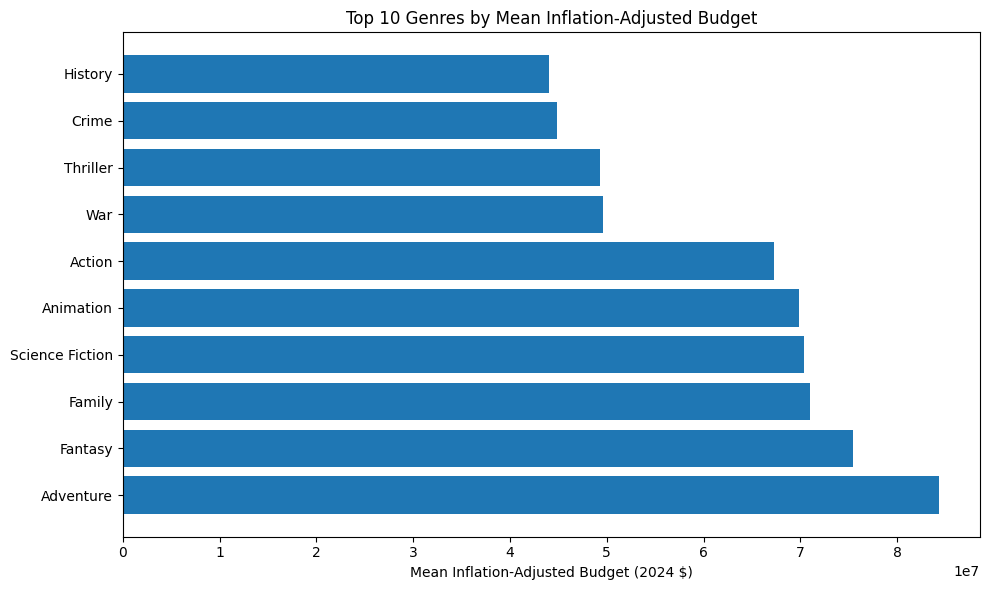

In [62]:
# Plot horizontal bar for mean budgets
plt.figure(figsize=(10, 6))
plt.barh(top10.index, top10['mean_budget'])
plt.xlabel('Mean Inflation‑Adjusted Budget (2024 $)')
plt.title('Top 10 Genres by Mean Inflation‑Adjusted Budget')
plt.tight_layout()
plt.show()

## I'm interesting in about the new datasets. This dataset include the social media infors
- Such as, facebook likes for movies, directors, actors, total cast Facebook likes. And some another num_critic_for_reviews, num_user_for_reviews, facenumber_in_poster, and aspect_ratio.
- Reference:
- New data from: https://github.com/sundeepblue/movie_rating_prediction

In [105]:
df = pd.read_csv('data/movie_metadata.csv')

In [108]:
df.head(1)

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000


In [106]:
df['imdb_score']

0       7.9
1       7.1
2       6.8
3       8.5
4       7.1
       ... 
5038    7.7
5039    7.5
5040    6.3
5041    6.3
5042    6.6
Name: imdb_score, Length: 5043, dtype: float64

In [107]:
df.columns.tolist()

['color',
 'director_name',
 'num_critic_for_reviews',
 'duration',
 'director_facebook_likes',
 'actor_3_facebook_likes',
 'actor_2_name',
 'actor_1_facebook_likes',
 'gross',
 'genres',
 'actor_1_name',
 'movie_title',
 'num_voted_users',
 'cast_total_facebook_likes',
 'actor_3_name',
 'facenumber_in_poster',
 'plot_keywords',
 'movie_imdb_link',
 'num_user_for_reviews',
 'language',
 'country',
 'content_rating',
 'budget',
 'title_year',
 'actor_2_facebook_likes',
 'imdb_score',
 'aspect_ratio',
 'movie_facebook_likes']

In [72]:
df['movie_imdb_link']

0       http://www.imdb.com/title/tt0499549/?ref_=fn_t...
1       http://www.imdb.com/title/tt0449088/?ref_=fn_t...
2       http://www.imdb.com/title/tt2379713/?ref_=fn_t...
3       http://www.imdb.com/title/tt1345836/?ref_=fn_t...
4       http://www.imdb.com/title/tt5289954/?ref_=fn_t...
                              ...                        
5038    http://www.imdb.com/title/tt3000844/?ref_=fn_t...
5039    http://www.imdb.com/title/tt2071645/?ref_=fn_t...
5040    http://www.imdb.com/title/tt2107644/?ref_=fn_t...
5041    http://www.imdb.com/title/tt2070597/?ref_=fn_t...
5042    http://www.imdb.com/title/tt0378407/?ref_=fn_t...
Name: movie_imdb_link, Length: 5043, dtype: object

- Well, since, we can merge this data based on the link
- Such as,  http://www.imdb.com/title/tt0499549/?ref_=fn_t..
- Check does tt0499549 is match with our imdb_id number??

In [73]:
test_datasets = pd.read_csv('result/test_budget_adjusted.csv');

In [86]:
print(test_datasets[test_datasets['imdb_id'] == 'tt0499549']
      [['title', 'release_year', 'budget', 'budget_adjusted']]
      .to_string())

       title  release_year        budget  budget_adjusted
3151  Avatar        2009.0  1.516326e+08     2.193353e+08


In [87]:
df.head(1)

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000


### YES, this is proved match !!!! 
- Hence, I will merge with data and test datasets, because some new data is into the test or train sets
- After merege, I'm rename called: IMDB_merged.csv
- This new datasets contain: 9,073 movies
- Because i'm merge the train_budget_adjusted.csv, test_budget_adjusted, and movie_metadata.
-  i'm using the Split_and_merge.py to finshed this work

In [88]:
df = pd.read_csv('result/IMDB_merged.csv')

In [91]:
df.head()

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,...,cast,crew,revenue,tconst,averageRating,release_year,release_month,release_day,budget_adjusted,budget_adjusted_log
0,1.0,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000.0,['Comedy'],NaN,tt2637294,en,Hot Tub Time Machine 2,When Lou who has become the father of the Inte...,6.575393,...,"[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651.0,tt2637294,5.0,2015.0,2.0,20.0,1.833018e+07,16.724059
1,2.0,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000.0,"['Comedy', 'Drama', 'Family', 'Romance']",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,...,"[{'cast_id': 1, 'character': 'Mia Thermopolis'...","[{'credit_id': '52fe43fe9251416c7502563d', 'de...",95149435.0,tt0368933,5.9,2004.0,8.0,6.0,6.355883e+07,17.967477
2,3.0,NaN,3300000.0,['Drama'],http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,Under the direction of a ruthless instructor a...,44.775274,...,"[{'cast_id': 5, 'character': 'Andrew Neimann',...","[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",13092000.0,tt2582802,8.5,2014.0,10.0,10.0,4.325814e+06,15.280111
3,4.0,NaN,1200000.0,"['Thriller', 'Drama']",http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi Vidya Balan arrives in Kolkata fr...,3.174936,...,"[{'cast_id': 1, 'character': 'Vidya Bagchi', '...","[{'credit_id': '52fe48779251416c9108d6eb', 'de...",16000000.0,tt1821480,8.1,2012.0,3.0,9.0,1.621955e+06,14.299144
4,5.0,NaN,16000000.0,"['Action', 'Thriller']",NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,...,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...","[{'credit_id': '52fe464b9251416c75073b43', 'de...",3923970.0,tt1380152,5.7,2009.0,2.0,5.0,2.314387e+07,16.957240


In [90]:
len(df)

9073

In [92]:
# I think this data should be clean data.
df.columns.tolist()

['id',
 'belongs_to_collection',
 'budget',
 'genres',
 'homepage',
 'imdb_id',
 'original_language',
 'original_title',
 'overview',
 'popularity',
 'poster_path',
 'production_companies',
 'production_countries',
 'release_date',
 'runtime',
 'spoken_languages',
 'status',
 'tagline',
 'title',
 'Keywords',
 'cast',
 'crew',
 'revenue',
 'tconst',
 'averageRating',
 'release_year',
 'release_month',
 'release_day',
 'budget_adjusted',
 'budget_adjusted_log']

In [95]:
df.shape

(9073, 30)